In [1]:
import analyze
import pandas as pd

In [2]:
df = analyze.load_dataset("./data/processed/feature_dataset.csv")
df

/home/balabanov.fedor/vmk/dvm-crystal/analyze.py:13: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,sequential_execution_time,average_parallel_line_executions,parallel_execution_fraction,arrays_count,total_array_elements,total_array_size_bytes,avg_array_size_bytes,max_array_dimension,min_array_dimension,avg_array_dimension,...,parallelism_degree,is_power_of_two_threads,is_power_of_two_grid,potential_contention,oversubscription_factor,target_speedup,parallel_execution_time,program_name,launch_config,normalized_parallel_time
0,0.0,2.305843e+18,1.0,3,3,12,4.0,1,1,1.0,...,1,1,1,0,1.0,1.000000,0.0002,cons2488,grid=[1]_threads=1,NaN
1,0.0,2.305843e+18,1.0,3,3,12,4.0,1,1,1.0,...,16,1,1,1,4.0,0.333333,0.0006,cons2488,grid=[4]_threads=4,NaN
2,0.0,2.305843e+18,1.0,3,3,12,4.0,1,1,1.0,...,9,0,0,1,3.0,0.400000,0.0005,cons2488,grid=[3]_threads=3,NaN
3,0.0,2.305843e+18,1.0,3,3,12,4.0,1,1,1.0,...,4,1,1,1,2.0,0.666667,0.0003,cons2488,grid=[2]_threads=2,NaN
4,0.0,2.305843e+18,1.0,3,3,12,4.0,1,1,1.0,...,3,0,1,1,3.0,1.000000,0.0002,cons2488,grid=[1]_threads=3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226092,0.0,3.074457e+18,1.0,4,4,16,4.0,1,1,1.0,...,4,1,1,1,2.0,0.333333,0.0003,cons3310,grid=[2]_threads=2,NaN
226093,0.0,3.074457e+18,1.0,4,4,16,4.0,1,1,1.0,...,3,0,1,1,3.0,1.000000,0.0001,cons3310,grid=[1]_threads=3,NaN
226094,0.0,3.074457e+18,1.0,4,4,16,4.0,1,1,1.0,...,8,1,1,1,4.0,0.333333,0.0003,cons3310,grid=[2]_threads=4,NaN
226095,0.0,3.074457e+18,1.0,4,4,16,4.0,1,1,1.0,...,4,1,1,1,4.0,1.000000,0.0001,cons3310,grid=[1]_threads=4,NaN


In [3]:
target_col = "parallel_execution_time"
name_col = "program_name"

zeros_only = df.groupby(name_col)[target_col].apply(lambda s: (s < 0.01).all())
programs = zeros_only[zeros_only].index.tolist()

pd.Series(programs, name=name_col).to_csv("fast_programs.csv", index=False)

In [13]:
tmp = pd.DataFrame(df.loc[df[target_col] > 0.1, name_col].unique())
tmp.to_csv("slow_programs.csv", index=False, header=name_col)

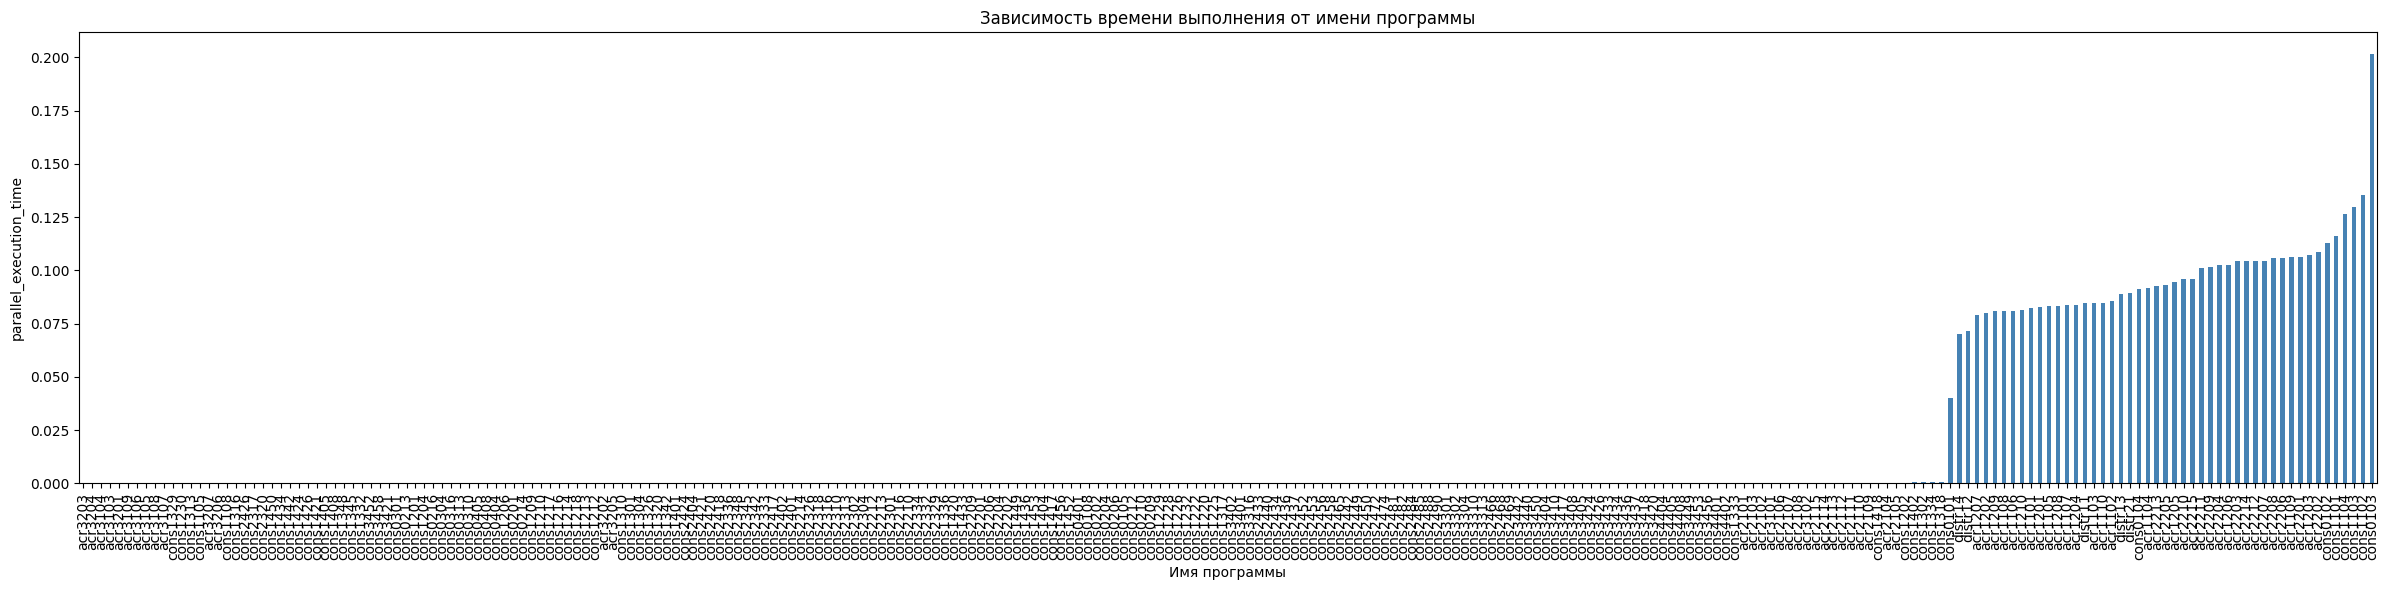

In [6]:
import matplotlib.pyplot as plt

program_time = (
    df.groupby(name_col)[target_col]
    .median()  # можно заменить на mean(), если нужен средний показатель
    .sort_values()
)

plt.figure(figsize=(24, 6))
program_time.plot(kind="bar", color="steelblue")
plt.title("Зависимость времени выполнения от имени программы")
plt.xlabel("Имя программы")
plt.ylabel(target_col)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()